# Thesis — Estimation: Kyoto Protocol and Carbon Leakage

Difference-in-differences estimates of the effect of Annex B ratification (binding emission
commitments, entry into force 2005) on the gap between consumption- and production-based CO2.

**Pre-committed design** (fixed in the Methodology chapter — do not change after seeing results):

| | |
|---|---|
| Treatment | `annex_b = 1` (34 Annex B ratifiers, USA excluded — signed but never ratified) |
| Timing | Single adoption date 2005 → no staggered adoption → TWFE + event study is the main spec |
| Primary outcome | `gap_share_pro` = (consumption − production) / production |
| Secondary outcome | `transfer_pc` = (consumption − production) / population, tonnes per person |
| Robustness outcome | `asinh(transfer / θ)`, θ = 3.755 Mt = pre-2005 median absolute transfer |
| Excluded outcome | `ln_con_pc` — fails the pre-trend test (−0.0173/yr, p = 0.003) |
| Inference | SEs clustered by country (119 clusters, 34 treated) |

Both primary and secondary outcomes are reported **regardless of sign**. The naive 2×2 gives
them opposite signs; persistent disagreement is itself a result, not a reason to pick one.

Sections below follow the estimation order: sample lock → descriptives → naive 2×2 →
TWFE → event study → pre-trend test → robustness.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

DATA = Path('Data/data_final_clean.csv')
OUT  = Path('output'); OUT.mkdir(exist_ok=True)

df = pd.read_csv(DATA)
print(df.shape, df.ISO3.nunique(), 'countries,', df.Year.min(), '-', df.Year.max())
df.head()

(4032, 22) 119 countries, 1990 - 2023


,Country,ISO3,Year,Consumption_Emissions,Production_Emissions,transfer,transfer_pc,Consumption_Emissions_pc,Production_Emissions_pc,gap_share_pro,gap_share_con,GDP_per_capita,Trade_Openness,Population,annex_b,first_treat,post,rel_year,country_id,first_treat_2008,post_2008,rel_year_2008
0,Albania,ALB,1990,5.573464,5.520602,0.052862,0.016127,1.700281,1.684155,0.009575,0.009485,5560.833935,39.436963,3277966,0,0,0,NaN,0,0,0,NaN
1,Albania,ALB,1991,4.616082,4.290226,0.325857,0.099268,1.406227,1.306959,0.075953,0.070592,4027.888807,36.070520,3282602,0,0,0,NaN,0,0,0,NaN
2,Albania,ALB,1992,2.924931,2.517116,0.407815,0.124239,0.891068,0.766829,0.162017,0.139427,3761.139808,108.785472,3282501,0,0,0,NaN,0,0,0,NaN
3,Albania,ALB,1993,2.674815,2.337999,0.336816,0.102756,0.816033,0.713277,0.144062,0.125921,4145.902505,80.518333,3277825,0,0,0,NaN,0,0,0,NaN
4,Albania,ALB,1994,2.365348,1.923806,0.441542,0.135052,0.723478,0.588426,0.229515,0.186671,4517.780079,53.102585,3269410,0,0,0,NaN,0,0,0,NaN


In [2]:
THETA = 3.755                                    # pre-2005 median |transfer|, Mt
df['ihs_scaled'] = np.arcsinh(df.transfer / THETA) # Chen & Roth scaling
df['ln_gdp_pc']  = np.log(df.GDP_per_capita)
df['treat_post'] = df.annex_b * (df.Year >= 2005).astype(int)

OUTCOMES = {
    'gap_share_pro': 'gap share (production denominator)  [PRIMARY]',
    'transfer_pc':   'net transfer per capita, t/person   [SECONDARY]',
    'ihs_scaled':    'asinh(transfer / 3.755)             [ROBUSTNESS]',
}

print(f"\nanalysis sample: {df.shape[0]} rows, {df.ISO3.nunique()} countries, "
      f"{df.loc[df.annex_b == 1, 'ISO3'].nunique()} treated / "
      f"{df.loc[df.annex_b == 0, 'ISO3'].nunique()} never-treated")


analysis sample: 4032 rows, 119 countries, 34 treated / 85 never-treated


In [3]:
df.head()

,Country,ISO3,Year,Consumption_Emissions,Production_Emissions,transfer,transfer_pc,Consumption_Emissions_pc,Production_Emissions_pc,gap_share_pro,gap_share_con,GDP_per_capita,Trade_Openness,Population,annex_b,first_treat,post,rel_year,country_id,first_treat_2008,post_2008,rel_year_2008,ihs_scaled,ln_gdp_pc,treat_post
0,Albania,ALB,1990,5.573464,5.520602,0.052862,0.016127,1.700281,1.684155,0.009575,0.009485,5560.833935,39.436963,3277966,0,0,0,NaN,0,0,0,NaN,0.014077,8.623503,0
1,Albania,ALB,1991,4.616082,4.290226,0.325857,0.099268,1.406227,1.306959,0.075953,0.070592,4027.888807,36.070520,3282602,0,0,0,NaN,0,0,0,NaN,0.086671,8.300998,0
2,Albania,ALB,1992,2.924931,2.517116,0.407815,0.124239,0.891068,0.766829,0.162017,0.139427,3761.139808,108.785472,3282501,0,0,0,NaN,0,0,0,NaN,0.108393,8.232477,0
3,Albania,ALB,1993,2.674815,2.337999,0.336816,0.102756,0.816033,0.713277,0.144062,0.125921,4145.902505,80.518333,3277825,0,0,0,NaN,0,0,0,NaN,0.089578,8.329876,0
4,Albania,ALB,1994,2.365348,1.923806,0.441542,0.135052,0.723478,0.588426,0.229515,0.186671,4517.780079,53.102585,3269410,0,0,0,NaN,0,0,0,NaN,0.117318,8.415776,0


## 2. Table 1 — pre-2005 balance

Normalised difference = (mean_treated − mean_control) / sqrt((var_T + var_C)/2).
Above ~0.25 in absolute value is conventionally "imbalanced".

The point of this table is that the treated and control groups are **very** different in income
and in emissions levels — which is exactly why the outcome is a *gap* measure (where balance is
good, 0.051) rather than an emissions level.

In [4]:
pre = df[df.Year < 2005]
rows = []
for v in ['gap_share_pro', 'transfer_pc', 'ihs_scaled',
          'GDP_per_capita','Consumption_Emissions_pc', 'Production_Emissions_pc', 'Trade_Openness']:
    t = pre.loc[pre.annex_b == 1, v].dropna()
    c = pre.loc[pre.annex_b == 0, v].dropna()
    rows.append([v, t.mean(), c.mean(), (t.mean() - c.mean()) / np.sqrt((t.var() + c.var()) / 2)])

table1 = pd.DataFrame(rows, columns=['variable', 'Annex B', 'non-Annex B', 'norm. diff'])
table1.to_csv(OUT / 'table1_balance.csv', index=False)
table1.round(3)

,variable,Annex B,non-Annex B,norm. diff
0,gap_share_pro,0.170,0.149,0.051
1,transfer_pc,1.163,-0.227,0.454
2,ihs_scaled,1.002,-0.056,0.499
3,GDP_per_capita,35715.083,14913.789,1.038
4,Consumption_Emissions_pc,10.743,4.436,1.022
5,Production_Emissions_pc,9.580,4.663,0.702
6,Trade_Openness,78.727,74.078,0.100


## 3. Naive 2×2 difference-in-differences

Group means only, no fixed effects. This goes in the results chapter as a **benchmark**, to show
what the uncontrolled comparison says before the FE do any work. It is not a result.

In [5]:
rows = []
for y in OUTCOMES:
    m = df.groupby([df.annex_b, df.Year >= 2005])[y].mean().unstack()
    did = (m.loc[1, True] - m.loc[1, False]) - (m.loc[0, True] - m.loc[0, False])
    rows.append([y, m.loc[1, False], m.loc[1, True], m.loc[0, False], m.loc[0, True], did])

naive = pd.DataFrame(rows, columns=['outcome', 'T pre', 'T post', 'C pre', 'C post', 'DiD'])
naive.to_csv(OUT / 'table2_naive_2x2.csv', index=False)
naive.round(4)

,outcome,T pre,T post,C pre,C post,DiD
0,gap_share_pro,0.1697,0.3047,0.1487,0.3588,-0.0750
1,transfer_pc,1.1628,1.8403,-0.2268,0.4075,0.0432
2,ihs_scaled,1.0019,1.4917,-0.0560,0.4382,-0.0044


## 4. Main specification — two-way fixed effects (TWFE)

$$Y_{it} = \beta \,(\text{AnnexB}_i \times \text{Post}_t) + \alpha_i + \gamma_t + \varepsilon_{it}$$

Country FE absorb every time-invariant difference (income level, geography, industrial
structure at baseline); year FE absorb common shocks (the 2008 crisis, the China trade boom).
SEs clustered by country. **β is the headline number of the thesis.**

In [6]:
def twfe(y, data, extra=''):
    """TWFE with country + year FE, SEs clustered by country."""
    dd = data.dropna(subset=[y] + ([c.strip() for c in extra.split('+') if c.strip()])).copy()
    f = f"{y} ~ treat_post {extra} + C(ISO3) + C(Year)"
    return smf.ols(f, data=dd).fit(cov_type='cluster', cov_kwds={'groups': dd.ISO3})

def row(y, r, label, data):
    b, se, p = r.params['treat_post'], r.bse['treat_post'], r.pvalues['treat_post']
    base = data.loc[(data.annex_b == 1) & (data.Year < 2005), y].mean()
    return dict(spec=label, outcome=y, beta=b, se=se, t=b / se, p=p,
                ci_lo=b - 1.96 * se, ci_hi=b + 1.96 * se,
                N=int(r.nobs), pre_treated_mean=base,
                pct_of_baseline=100 * b / base if base else np.nan)

main = pd.DataFrame([row(y, twfe(y, df), 'TWFE', df) for y in OUTCOMES])
main.to_csv(OUT / 'table3_twfe_main.csv', index=False)
main.round(4)

,spec,outcome,beta,se,t,p,ci_lo,ci_hi,N,pre_treated_mean,pct_of_baseline
0,TWFE,gap_share_pro,-0.0702,0.0732,-0.9586,0.3378,-0.2136,0.0733,4029,0.1697,-41.3518
1,TWFE,transfer_pc,0.0527,0.3478,0.1515,0.8796,-0.6289,0.7343,4029,1.1628,4.5316
2,TWFE,ihs_scaled,0.0019,0.1924,0.0098,0.9921,-0.3753,0.3791,4029,1.0019,0.1891


### 4b. With a time-varying control

`ln(GDP per capita)` only. **Trade openness is deliberately excluded**: its correlation with
`gap_share` is +0.14 pooled but −0.02 *within* country, so under country FE it contributes
nothing and it is plausibly a post-treatment outcome of the treaty itself (bad control).

In [7]:
ctrl = pd.DataFrame([row(y, twfe(y, df, extra='+ ln_gdp_pc'), 'TWFE + ln GDPpc', df)
                     for y in OUTCOMES])
ctrl.to_csv(OUT / 'table4_twfe_controls.csv', index=False)
ctrl.round(4)

,spec,outcome,beta,se,t,p,ci_lo,ci_hi,N,pre_treated_mean,pct_of_baseline
0,TWFE + ln GDPpc,gap_share_pro,-0.0739,0.0685,-1.0790,0.2806,-0.2082,0.0604,3995,0.1697,-43.5711
1,TWFE + ln GDPpc,transfer_pc,0.0221,0.3327,0.0664,0.9470,-0.6301,0.6743,3995,1.1628,1.9006
2,TWFE + ln GDPpc,ihs_scaled,-0.0188,0.1902,-0.0990,0.9212,-0.3917,0.3540,3995,1.0019,-1.8786


## 5. Event study

$$Y_{it} = \sum_{k \neq -1} \delta_k \,\mathbb{1}[t - 2005 = k]\cdot \text{AnnexB}_i
        + \alpha_i + \gamma_t + \varepsilon_{it}$$

`k = −1` (2004) is the omitted reference period; never-treated countries sit in the reference
bin throughout and identify the year effects. Endpoints are binned.

This figure is the single most important exhibit in the thesis — it carries the pre-trend
evidence *and* the post-2005 dynamics in one picture.

In [8]:
def event_study(y, data, lo=-11, hi=18, start_year=None):
    e = data.copy()
    if start_year:
        e = e[e.Year >= start_year]
    e = e.dropna(subset=[y]).copy()
    e['ev'] = np.where(e.annex_b == 1, (e.Year - 2005).clip(lo, hi), -1).astype(int)
    r = smf.ols(f"{y} ~ C(ev, Treatment(reference=-1)) + C(ISO3) + C(Year)",
                data=e).fit(cov_type='cluster', cov_kwds={'groups': e.ISO3})
    ks = [k for k in r.params.index if k.startswith('C(ev')]
    out = pd.DataFrame({
        'k':    [int(k.split('T.')[1].rstrip(']')) for k in ks],
        'coef': [r.params[k] for k in ks],
        'se':   [r.bse[k]    for k in ks],
    }).sort_values('k')
    out.loc[len(out)] = {'k': -1, 'coef': 0.0, 'se': 0.0}   # reference period
    return out.sort_values('k').reset_index(drop=True), r, ks


def plot_event(es, title, ylab, fname):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.errorbar(es.k, es.coef, yerr=1.96 * es.se, fmt='o-', capsize=3,
                color='#1f4e79', ecolor='#9bb8d3', markersize=4, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(-0.5, color='crimson', linestyle='--', linewidth=1)
    ax.text(-0.4, ax.get_ylim()[1] * 0.92, ' Kyoto in force (2005)',
            color='crimson', fontsize=9)
    ax.set_xlabel('Years relative to 2005')
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(fname, dpi=200)
    plt.show()


es_gap, r_gap, ks_gap = event_study('gap_share_pro', d)
plot_event(es_gap, 'Event study — gap share (production denominator)',
           'Coefficient (ref = 2004)', OUT / 'fig_event_gap_share.png')
es_gap.round(4)

NameError: name 'd' is not defined

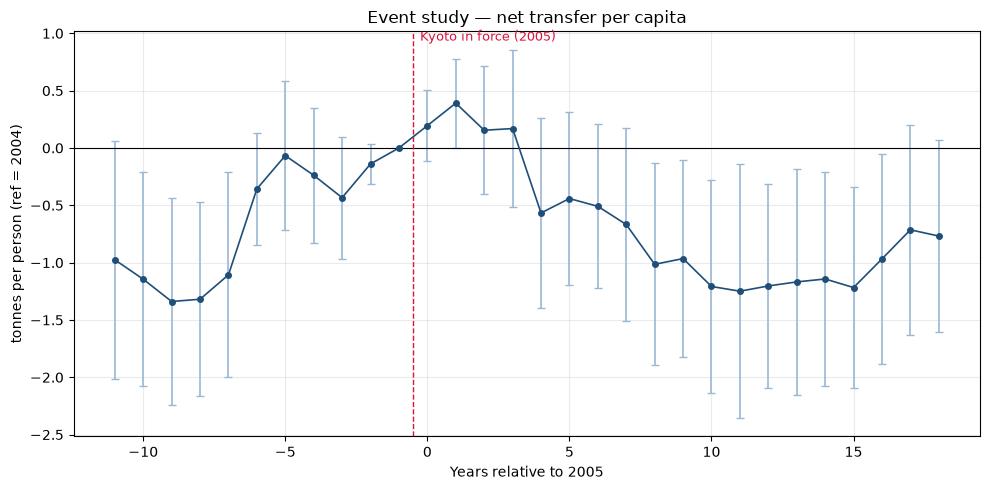

,k,coef,se
0,-11,-0.9754,0.5292
1,-10,-1.1444,0.4750
2,-9,-1.3390,0.4613
3,-8,-1.3192,0.4312
4,-7,-1.1062,0.4569
5,-6,-0.3566,0.2508
6,-5,-0.0666,0.3328
7,-4,-0.2381,0.2998
8,-3,-0.4335,0.2711
9,-2,-0.1391,0.0875


In [ ]:
es_tpc, r_tpc, ks_tpc = event_study('transfer_pc', df)
plot_event(es_tpc, 'Event study — net transfer per capita',
           'tonnes per person (ref = 2004)', OUT / 'fig_event_transfer_pc.png')
es_tpc.round(4)

## 6. Joint pre-trend test

Formal test that **all** pre-2005 leads are jointly zero. This is the paper-grade version of the
linear pre-trend regression run in the EDA — and it is a strictly harder test: a linear-trend
test only detects a *straight line*, so it can pass while the leads still wander.

Read the result honestly. If it rejects, the parallel-trends assumption is not clean and the
thesis must say so in the Limitations section rather than hide it.

In [ ]:
def joint_pretrend(r, ks):
    leads = [k for k in ks if int(k.split('T.')[1].rstrip(']')) < 0]
    ft = r.f_test(' = 0, '.join(leads) + ' = 0')
    return float(ft.fvalue), float(ft.pvalue), len(leads)

pt = pd.DataFrame([
    dict(zip(['F', 'p', 'n_leads'], joint_pretrend(r_gap, ks_gap)), outcome='gap_share_pro'),
    dict(zip(['F', 'p', 'n_leads'], joint_pretrend(r_tpc, ks_tpc)), outcome='transfer_pc'),
])[['outcome', 'n_leads', 'F', 'p']]
pt.to_csv(OUT / 'table5_pretrend.csv', index=False)
pt.round(4)

,outcome,n_leads,F,p
0,gap_share_pro,10,2.2045,0.0219
1,transfer_pc,10,2.0574,0.0333


### 6b. Sensitivity of the pre-trend to the pre-window

Shortening the pre-period mechanically weakens the test (fewer leads to reject on). Check
whether the ATT moves when it does — if the post-2005 coefficients are unchanged, trimming the
pre-window is **cosmetic** and must not be presented as having fixed anything.

In [ ]:
rows = []
for y in OUTCOMES:
    for start, lo in [(1990, -11), (1995, -10), (1998, -7), (2000, -5)]:
        es, r, ks = event_study(y, df, lo=lo, start_year=start)
        F, p, n = joint_pretrend(r, ks)
        att = es.loc[es.k >= 0, 'coef'].mean()
        rows.append([y, start, n, F, p, att])

pd.DataFrame(rows, columns=['outcome', 'pre-window from', 'n_leads',
                            'F', 'p', 'avg post coef']).round(4)

,outcome,pre-window from,n_leads,F,p,avg post coef
0,gap_share_pro,1990,10,2.2045,0.0219,-0.0789
1,gap_share_pro,1995,9,2.4332,0.0142,-0.0788
2,gap_share_pro,1998,6,1.6153,0.1488,-0.0788
3,gap_share_pro,2000,4,2.1264,0.0818,-0.0788
4,transfer_pc,1990,10,2.0574,0.0333,-0.6785
5,transfer_pc,1995,9,2.1838,0.0278,-0.6784
6,transfer_pc,1998,6,1.7758,0.1098,-0.6783
7,transfer_pc,2000,4,2.1896,0.0743,-0.6782
8,ihs_scaled,1990,10,1.1956,0.3009,-0.3581
9,ihs_scaled,1995,9,1.1693,0.3210,-0.3580


## 7. Robustness

In priority order. **7a belongs in the main text**, not the appendix.

### 7a. Drop the 13 economies in transition

The single biggest confounder in this design: 13 of the 34 treated units are post-Soviet
economies whose emissions collapsed in the 1990s for reasons that have nothing to do with
Kyoto. If the result only exists with them in the sample, it is not a treaty effect.

In [ ]:
EIT = ['BGR','CZE','EST','HRV','HUN','LTU','LVA','POL','ROU','RUS','SVK','SVN','UKR']
df_noeit = df[~df.ISO3.isin(EIT)]
print('treated countries remaining:', df_noeit.loc[df_noeit.annex_b == 1, 'ISO3'].nunique())

rob_eit = pd.DataFrame([row(y, twfe(y, df_noeit), 'drop EIT', df_noeit) for y in OUTCOMES])
rob_eit.round(4)

treated countries remaining: 21


,spec,outcome,beta,se,t,p,ci_lo,ci_hi,N,pre_treated_mean,pct_of_baseline
0,drop EIT,gap_share_pro,-0.0553,0.0906,-0.6102,0.5417,-0.2330,0.1224,3587,0.2338,-23.6611
1,drop EIT,transfer_pc,0.0164,0.4673,0.0351,0.9720,-0.8995,0.9324,3587,1.8730,0.8766
2,drop EIT,ihs_scaled,-0.2111,0.2244,-0.9405,0.3469,-0.6510,0.2288,3587,2.1703,-9.7264


### 7b. Alternative treatment date — 2008

2005 is entry into force; 2008 is the start of the first commitment period, when the binding
targets actually began to bite. A leakage effect should be at least as visible from 2008.

In [ ]:
d8 = df.copy()
d8['treat_post'] = d8.annex_b * (d8.Year >= 2008).astype(int)
rob_2008 = pd.DataFrame([row(y, twfe(y, d8), 'treat from 2008', d8) for y in OUTCOMES])
rob_2008.round(4)

,spec,outcome,beta,se,t,p,ci_lo,ci_hi,N,pre_treated_mean,pct_of_baseline
0,treat from 2008,gap_share_pro,-0.0857,0.0808,-1.0608,0.2888,-0.2440,0.0726,4029,0.1697,-50.5048
1,treat from 2008,transfer_pc,-0.2877,0.3496,-0.8230,0.4105,-0.9728,0.3974,4029,1.1628,-24.7406
2,treat from 2008,ihs_scaled,-0.1694,0.1941,-0.8729,0.3827,-0.5499,0.2110,4029,1.0019,-16.9105


### 7c. Placebo — fake treatment in 1997

1997 is the Kyoto *signing*: an announcement with no binding obligation. Estimated on the
pre-2005 sample only. A large or significant coefficient here means the design is picking up
group divergence rather than the treaty.

In [ ]:
dp = df[df.Year < 2005].copy()
dp['treat_post'] = dp.annex_b * (dp.Year >= 1997).astype(int)
placebo = pd.DataFrame([row(y, twfe(y, dp), 'placebo 1997', dp) for y in OUTCOMES])
placebo.round(4)

,spec,outcome,beta,se,t,p,ci_lo,ci_hi,N,pre_treated_mean,pct_of_baseline
0,placebo 1997,gap_share_pro,-0.0349,0.0565,-0.6174,0.5369,-0.1456,0.0758,1771,0.1697,-20.5534
1,placebo 1997,transfer_pc,0.5932,0.4228,1.4030,0.1606,-0.2355,1.4220,1771,1.1628,51.0143
2,placebo 1997,ihs_scaled,0.2756,0.2100,1.3127,0.1893,-0.1359,0.6872,1771,1.0019,27.5105


### 7d. Leave-one-country-out

Checks that no single economy drives the estimate.

In [ ]:
loo = []
for iso in ['CHN', 'RUS', 'USA', 'IND', 'DEU', 'JPN', 'NOR', 'GBR']:
    dd = df[df.ISO3 != iso]
    r = twfe('gap_share_pro', dd)
    loo.append([iso, r.params['treat_post'], r.bse['treat_post'], r.pvalues['treat_post']])

pd.DataFrame(loo, columns=['dropped', 'beta', 'se', 'p']).round(4)

,dropped,beta,se,p
0,CHN,-0.0731,0.0737,0.3211
1,RUS,-0.0682,0.0739,0.3562
2,USA,-0.0721,0.0737,0.3284
3,IND,-0.0735,0.0737,0.3189
4,DEU,-0.0659,0.0738,0.3721
5,JPN,-0.0636,0.0737,0.3879
6,NOR,-0.0698,0.0734,0.3415
7,GBR,-0.0720,0.0739,0.3305


## 8. Assemble the results 

In [ ]:
full = pd.concat([main, ctrl, rob_eit, rob_2008, placebo], ignore_index=True)
full.to_csv(OUT / 'table_all_specifications.csv', index=False)
full.round(4)

,spec,outcome,beta,se,t,p,ci_lo,ci_hi,N,pre_treated_mean,pct_of_baseline
0,TWFE,gap_share_pro,-0.0702,0.0732,-0.9586,0.3378,-0.2136,0.0733,4029,0.1697,-41.3518
1,TWFE,transfer_pc,0.0527,0.3478,0.1515,0.8796,-0.6289,0.7343,4029,1.1628,4.5316
2,TWFE,ihs_scaled,0.0019,0.1924,0.0098,0.9921,-0.3753,0.3791,4029,1.0019,0.1891
3,TWFE + ln GDPpc,gap_share_pro,-0.0739,0.0685,-1.0790,0.2806,-0.2082,0.0604,3995,0.1697,-43.5711
4,TWFE + ln GDPpc,transfer_pc,0.0221,0.3327,0.0664,0.9470,-0.6301,0.6743,3995,1.1628,1.9006
5,TWFE + ln GDPpc,ihs_scaled,-0.0188,0.1902,-0.0990,0.9212,-0.3917,0.3540,3995,1.0019,-1.8786
6,drop EIT,gap_share_pro,-0.0553,0.0906,-0.6102,0.5417,-0.2330,0.1224,3587,0.2338,-23.6611
7,drop EIT,transfer_pc,0.0164,0.4673,0.0351,0.9720,-0.8995,0.9324,3587,1.8730,0.8766
8,drop EIT,ihs_scaled,-0.2111,0.2244,-0.9405,0.3469,-0.6510,0.2288,3587,2.1703,-9.7264
9,treat from 2008,gap_share_pro,-0.0857,0.0808,-1.0608,0.2888,-0.2440,0.0726,4029,0.1697,-50.5048
